In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans


In [3]:
image_path = "../output_videos/cropped_player_1.jpg"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


(np.float64(-0.5), np.float64(22.5), np.float64(57.5), np.float64(-0.5))

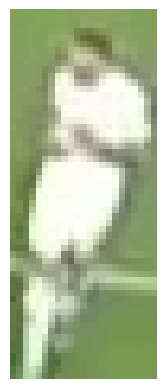

In [4]:
plt.imshow(image_rgb)
plt.axis('off')

# take the top half of the image

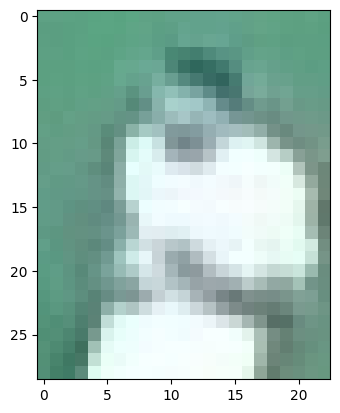

In [5]:
top_half_image = image[0: int(image.shape[0] / 2), :]
plt.imshow(top_half_image)
plt.show()

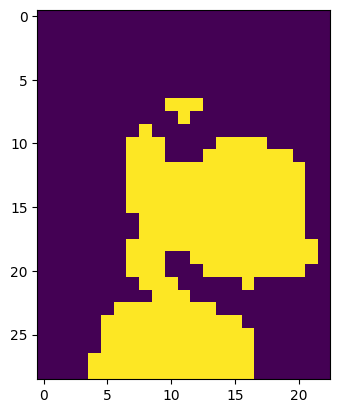

In [12]:
## cluster the image into two clusters

# reshape the image to a 2D array of pixels
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

# get the cluster labels
labels = kmeans.labels_


# reshape the labels back to the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# display the clustered image
plt.imshow(clustered_image)
plt.show()

In [13]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [14]:
player_cluster = 1-non_player_cluster
print(player_cluster)

1


In [15]:
kmeans.cluster_centers_[player_cluster]

array([226.84018265, 241.52968037, 240.78538813])